# Project submission

### Group number:
### Student IDs: 71362, (add you IDs here)
### Project name: Cryptocurrency Direction Forecasting and Algorithmic Trading Strategy

<a id="table-of-contents"></a>

## Inhaltsverzeichnis

1. [Project Introduction](#project-introduction)
   - [1.1 What business problem are you solving?](#business-problem)
   - [1.2 What is the machine learning problem that you are solving?](#machine-learning-problem)
2. [Data Exploration and Preparation](#data-exploration-preparation)
   - [2.1 Interpretation of the prepared modeling dataset](#prepared-modeling-dataset)
3. [Feature Engineering](#feature-engineering)
4. [Temporal Split](#temporal-split)
5. [Feature Analysis and Selection](#feature-analysis-selection)
   - [5.1 Feature overview](#feature-overview)
   - [5.2 EDA checks: missingness and target association](#eda-checks)
   - [5.3 Correlation and redundancy](#correlation-redundancy)
   - [5.4 Model-based feature importance](#model-based-feature-importance)
   - [5.5 PDP and ICE plots for the top features](#pdp-ice)
   - [5.6 Final include / neglect decision](#include-neglect)
6. [Modeling](#modeling)
   - [6.1 Baseline models](#baseline-models)
   - [6.2 Classical models with time-aware hyperparameter tuning](#classical-models)
   - [6.3 Interpretation of the classical model comparison](#classical-model-interpretation)
   - [6.4 Neural network](#neural-network)
   - [6.5 Interpretation of the neural network results](#neural-network-interpretation)
7. [Model Evaluation](#model-evaluation)
   - [7.1 Interpretation of the final test results](#final-test-interpretation)
8. [Model Interpretation](#model-interpretation)
   - [8.1 Interpretation of the feature importance results](#feature-importance-interpretation)
9. [Conclusion](#conclusion)


<a id="project-introduction"></a>

## 1. Project Introduction

<a id="business-problem"></a>

### 1.1 What business problem are you solving?

Crypto assets are highly volatile, and firms involved in crypto trading activity, such as exchanges, brokers, asset managers, or financial services platforms, face the problem of deciding when taking short-term market exposure is justified by the available data.

The business problem we solve is to build a simple algorithmic trading strategy that decides, at the end of each 4-hour candle, whether to take a long position in a cryptocurrency for the next 4-hour candle or stay out of the market. This is relevant because even a small improvement over random directional forecasts can be economically useful when converted into a disciplined and testable trading rule. The difficulty is not only to obtain a model that is accurate, but also to avoid overfitting noisy financial data and to make sure that the model is accurate and not too generalized.

<a id="machine-learning-problem"></a>

### 1.2 What is the machine learning problem that you are solving?

The machine learning problem is a binary classification problem. At the end of candle `t`, using only information available up to `t`, we predict whether the next valid 4-hour log return is positive.

The target is:

```python
future_return_4h = log(Close[t+1] / Close[t])
y = 1 if future_return_4h > 0 else 0
```

The output of each model is a probability `P(up)`. We transform this probability into a trading strategy:

```text
if P(up) >= threshold: take a long position for the next 4-hour candle
else: hold no position
```

Therefore the project has two evaluation layers. First, we evaluate the classification model with ROC AUC, precision, recall and F1. Second, we evaluate the trading rule with cumulative return, annualized Sharpe ratio, maximum drawdown and exposure.

<a id="data-exploration-preparation"></a>

## 2. Data Exploration and Preparation

The EDA notebook showed three important facts. First, the target should be based on returns, not raw future prices, because price levels are highly persistent and would make the task look easier without necessarily producing a useful trading strategy. Second, Maker has large structural gaps and is removed. Third, the other assets have only small residual gaps, so we keep them but prevent returns, targets, lags and rolling features from crossing non-4-hour gaps.

This cell loads the data, checks the structure, removes Maker, creates gap-aware returns and targets, and reports the final modeling sample.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

EXPECTED_FREQ = pd.Timedelta(hours=4)
TRANSACTION_COST = 0.001
CV_TRAIN_ROWS = 25_000

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

In [2]:
def resolve_data_path(filename="pr15_crypto.csv") -> Path:
    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in search_roots:
        candidate = root / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Unable to locate {filename}")


def load_raw_data():
    data_path = resolve_data_path()
    raw = pd.read_csv(data_path)
    if "Unnamed: 0" in raw.columns:
        raw = raw.drop(columns=["Unnamed: 0"])
    raw["timestamp"] = pd.to_datetime(raw["timestamp"])
    raw = raw.sort_values(["Asset_ID", "timestamp"]).reset_index(drop=True)
    return raw


raw_df = load_raw_data()

print("Raw dataset shape:", raw_df.shape)
display(raw_df.head())
print("Date range:", raw_df["timestamp"].min(), "to", raw_df["timestamp"].max())
print("Assets:", raw_df["Asset_Name"].nunique())
print("Duplicate asset-timestamps:", raw_df.duplicated(["Asset_ID", "timestamp"]).sum())
display(raw_df.isna().sum().to_frame("missing_values"))

Raw dataset shape: (104324, 11)


,Asset_ID,timestamp,Count,Open,High,Low,Close,Volume,VWAP,Weight,Asset_Name
0,0,2018-01-01 00:00:00,3272.0,8.5300,8.5300,8.1305,8.3401,136150.46,8.327702,4.304065,Binance Coin
1,0,2018-01-01 04:00:00,3231.0,8.3612,8.7000,8.3410,8.3600,100304.70,8.485586,4.304065,Binance Coin
2,0,2018-01-01 08:00:00,3412.0,8.3852,8.5300,8.0703,8.1604,113605.91,8.274129,4.304065,Binance Coin
3,0,2018-01-01 12:00:00,3678.0,8.1800,8.3300,7.8000,8.1101,156761.84,8.063121,4.304065,Binance Coin
4,0,2018-01-01 16:00:00,2030.0,8.1160,8.1778,7.9592,8.1150,61915.82,8.063309,4.304065,Binance Coin


Date range: 2018-01-01 00:00:00 to 2021-09-20 20:00:00
Assets: 14
Duplicate asset-timestamps: 0


,missing_values
Asset_ID,0
timestamp,0
Count,0
Open,0
High,0
Low,0
Close,0
Volume,0
VWAP,0
Weight,0


In [3]:
def add_gap_aware_target_and_features(raw):
    df = raw.loc[raw["Asset_Name"] != "Maker"].copy()
    df = df.sort_values(["Asset_ID", "timestamp"]).reset_index(drop=True)

    g_asset = df.groupby("Asset_ID", group_keys=False)
    df["prev_timestamp"] = g_asset["timestamp"].shift(1)
    df["next_timestamp"] = g_asset["timestamp"].shift(-1)
    df["prev_delta"] = df["timestamp"] - df["prev_timestamp"]
    df["next_delta"] = df["next_timestamp"] - df["timestamp"]
    df["valid_prev_4h"] = df["prev_delta"].eq(EXPECTED_FREQ)
    df["valid_next_4h"] = df["next_delta"].eq(EXPECTED_FREQ)

    df["new_segment"] = ~df["valid_prev_4h"]
    df["segment_id"] = df.groupby("Asset_ID")["new_segment"].cumsum().astype(int)

    df["Log_Close"] = np.log(df["Close"])
    df["Log_Return"] = np.where(
        df["valid_prev_4h"],
        df["Log_Close"] - g_asset["Log_Close"].shift(1),
        np.nan,
    )
    df["Future_Log_Return_4H"] = np.where(
        df["valid_next_4h"],
        g_asset["Log_Close"].shift(-1) - df["Log_Close"],
        np.nan,
    )
    df["Target_Up_4H"] = np.where(
        df["Future_Log_Return_4H"].notna(),
        (df["Future_Log_Return_4H"] > 0).astype(int),
        np.nan,
    )

    vwap_finite = np.isfinite(df["VWAP"])
    vwap_inside_range = df["VWAP"].between(df["Low"], df["High"], inclusive="both")
    df["VWAP_Clean"] = df["VWAP"].where(vwap_finite & vwap_inside_range, np.nan)

    df["High_Low_Range"] = (df["High"] - df["Low"]) / df["Open"]
    df["VWAP_Deviation"] = (df["Close"] - df["VWAP_Clean"]) / df["Close"]
    df["Log_Volume"] = np.log1p(df["Volume"])
    df["Log_Count"] = np.log1p(df["Count"])

    g_segment = df.groupby(["Asset_ID", "segment_id"], group_keys=False)
    df["Return_Current_4H"] = df["Log_Return"]
    df["Return_Lag_1"] = g_segment["Log_Return"].shift(1)
    df["Return_Lag_2"] = g_segment["Log_Return"].shift(2)
    df["Return_Lag_3"] = g_segment["Log_Return"].shift(3)
    df["Rolling_Return_Mean_6"] = g_segment["Log_Return"].transform(lambda s: s.rolling(6, min_periods=4).mean())
    df["Rolling_Volatility_6"] = g_segment["Log_Return"].transform(lambda s: s.rolling(6, min_periods=4).std())
    df["Rolling_Volatility_42"] = g_segment["Log_Return"].transform(lambda s: s.rolling(42, min_periods=24).std())
    df["Log_Count_Change_1"] = g_segment["Log_Count"].diff(1)

    return_pivot = df.pivot(index="timestamp", columns="Asset_ID", values="Log_Return")
    market_sum = return_pivot.sum(axis=1, skipna=True)
    market_count = return_pivot.count(axis=1)
    btc_return = return_pivot[1].rename("BTC_Return")
    eth_return = return_pivot[6].rename("ETH_Return")

    df["BTC_Return"] = df["timestamp"].map(btc_return)
    df["ETH_Return"] = df["timestamp"].map(eth_return)
    df["Market_Return_Ex_Asset"] = (df["timestamp"].map(market_sum) - df["Log_Return"]) / (df["timestamp"].map(market_count) - 1)
    return df


model_df = add_gap_aware_target_and_features(raw_df)

numeric_features = [
    "Return_Current_4H", "Return_Lag_1", "Return_Lag_2", "Return_Lag_3",
    "Rolling_Return_Mean_6", "Rolling_Volatility_6", "Rolling_Volatility_42",
    "High_Low_Range", "VWAP_Deviation", "Log_Volume", "Log_Count_Change_1",
    "Market_Return_Ex_Asset", "BTC_Return", "ETH_Return",
]
categorical_features = ["Asset_Name"]
feature_columns = numeric_features + categorical_features
target_col = "Target_Up_4H"
return_col = "Future_Log_Return_4H"

model_df = model_df[model_df[target_col].notna()].copy()
model_df[target_col] = model_df[target_col].astype(int)
model_df = model_df.sort_values("timestamp").reset_index(drop=True)

print("Modeling dataset after excluding Maker and invalid future targets:", model_df.shape)
print("Assets kept:", model_df["Asset_Name"].nunique())
print("Target up-rate:", round(model_df[target_col].mean(), 4))
display(model_df.groupby("Asset_Name").agg(rows=(target_col, "size"), up_rate=(target_col, "mean")).sort_values("rows", ascending=False))
display(model_df[feature_columns + [target_col, return_col]].isna().mean().sort_values(ascending=False).to_frame("missing_share"))

Modeling dataset after excluding Maker and invalid future targets: (101220, 39)
Assets kept: 13
Target up-rate: 0.5043


,rows,up_rate
Asset_Name,,
Bitcoin,8153,0.515638
Bitcoin Cash,8153,0.497976
EOS.IO,8153,0.504477
Ethereum,8153,0.508157
Ethereum Classic,8153,0.498344
Litecoin,8153,0.501288
Monero,8149,0.514419
Binance Coin,8133,0.512480
TRON,7932,0.504917


,missing_share
Rolling_Volatility_42,0.007410
Return_Lag_3,0.001413
Rolling_Return_Mean_6,0.001413
Rolling_Volatility_6,0.001413
Return_Lag_2,0.001067
Return_Lag_1,0.000721
Return_Current_4H,0.000366
Log_Count_Change_1,0.000366
Market_Return_Ex_Asset,0.000366
ETH_Return,0.000079


<a id="prepared-modeling-dataset"></a>

### 2.1 Interpretation of the prepared modeling dataset

The raw dataset has 104,324 observations, 11 variables, 14 assets, no missing values and no duplicate asset-timestamps. After removing Maker and invalid future-target rows, the modeling dataset has 101,220 observations and 13 assets. The target up-rate is approximately 50.4%, so the task is nearly balanced and accuracy alone would not be sufficient to judge performance.

The remaining missing values are created by lag and rolling-window construction, not by raw data quality problems. They are handled inside the modeling pipeline with median imputation, which is fit only on training data or training folds.

<a id="feature-engineering"></a>

## 3. Feature Engineering

The feature set follows the EDA conclusions and the course methodology on transformations, scaling, pipelines and leakage control. We do not use raw future information and we do not use raw price levels as direct predictors. Instead, every feature is observable at the end of candle `t`.

The features are grouped as follows:

- return dynamics: current return and short lags;
- local momentum/mean reversion: rolling mean of returns;
- risk regime: short and longer rolling volatility;
- candle pressure: high-low range and deviation from VWAP;
- liquidity/activity: log volume and change in log trade count;
- market context: BTC, ETH and equal-weighted market return excluding the asset itself;
- asset identity: one-hot encoded `Asset_Name`.

<a id="temporal-split"></a>

## 4. Temporal Split

Financial observations are time ordered, so we use a chronological split rather than a random split. The validation period is used for model selection and threshold selection. The test period is held out until the final evaluation.

For hyperparameter tuning, we use `TimeSeriesSplit` only within the training period. To keep the notebook executable, the grid search uses the most recent part of the training period and then refits the selected hyperparameters on the full training set.

In [4]:
train_end = pd.Timestamp("2020-12-31 23:59:59")
validation_end = pd.Timestamp("2021-05-31 23:59:59")

train_df = model_df[model_df["timestamp"] <= train_end].copy()
validation_df = model_df[(model_df["timestamp"] > train_end) & (model_df["timestamp"] <= validation_end)].copy()
test_df = model_df[model_df["timestamp"] > validation_end].copy()

X_train = train_df[feature_columns]
y_train = train_df[target_col]
X_validation = validation_df[feature_columns]
y_validation = validation_df[target_col]
X_test = test_df[feature_columns]
y_test = test_df[target_col]

train_tuning_df = train_df.tail(min(CV_TRAIN_ROWS, len(train_df))).copy()
X_train_tuning = train_tuning_df[feature_columns]
y_train_tuning = train_tuning_df[target_col]

split_summary = []
for split_name, part in [("train", train_df), ("validation", validation_df), ("test", test_df), ("train_tuning", train_tuning_df)]:
    split_summary.append({
        "split": split_name,
        "rows": len(part),
        "start": part["timestamp"].min(),
        "end": part["timestamp"].max(),
        "up_rate": part[target_col].mean(),
    })

display(pd.DataFrame(split_summary))

,split,rows,start,end,up_rate
0,train,80719,2018-01-01 00:00:00,2020-12-31 20:00:00,0.500564
1,validation,11778,2021-01-01 00:00:00,2021-05-31 20:00:00,0.535150
2,test,8723,2021-06-01 00:00:00,2021-09-20 16:00:00,0.497535
3,train_tuning,25000,2020-02-15 08:00:00,2020-12-31 20:00:00,0.516640


<a id="feature-analysis-selection"></a>

## 5. Feature Analysis and Selection

This section follows the same simple process as the ML class notebooks: first EDA checks, then correlation/redundancy, then model-based importance, then PDP/ICE plots, and finally a clear include/neglect table.

The feature decision is made before the final model comparison and does not use the test set.

<a id="feature-overview"></a>

### 5.1 Feature Overview

The table below gives the business intuition for each candidate numeric feature. `Asset_Name` is kept separately as a categorical control, because different crypto assets can have different average behavior.

In [5]:
feature_overview = pd.DataFrame([
    {"feature": "Return_Current_4H", "group": "own returns", "intuition": "current 4-hour return pressure"},
    {"feature": "Return_Lag_1", "group": "own returns", "intuition": "previous 4-hour return"},
    {"feature": "Return_Lag_2", "group": "own returns", "intuition": "return two candles ago"},
    {"feature": "Return_Lag_3", "group": "own returns", "intuition": "return three candles ago"},
    {"feature": "Rolling_Return_Mean_6", "group": "trend", "intuition": "average return over the recent 24 hours"},
    {"feature": "Rolling_Volatility_6", "group": "volatility", "intuition": "short-term volatility over the recent 24 hours"},
    {"feature": "Rolling_Volatility_42", "group": "volatility", "intuition": "longer volatility over roughly one week"},
    {"feature": "High_Low_Range", "group": "candle pressure", "intuition": "within-candle price range"},
    {"feature": "VWAP_Deviation", "group": "candle pressure", "intuition": "close price position versus VWAP"},
    {"feature": "Log_Volume", "group": "liquidity", "intuition": "trading volume"},
    {"feature": "Log_Count_Change_1", "group": "liquidity", "intuition": "change in number of trades"},
    {"feature": "Market_Return_Ex_Asset", "group": "cross-asset", "intuition": "crypto market return excluding the asset itself"},
    {"feature": "BTC_Return", "group": "cross-asset", "intuition": "Bitcoin return as market leader"},
    {"feature": "ETH_Return", "group": "cross-asset", "intuition": "Ethereum return as smart-contract market leader"},
])

display(feature_overview)

,feature,group,intuition
0,Return_Current_4H,own returns,current 4-hour return pressure
1,Return_Lag_1,own returns,previous 4-hour return
2,Return_Lag_2,own returns,return two candles ago
3,Return_Lag_3,own returns,return three candles ago
4,Rolling_Return_Mean_6,trend,average return over the recent 24 hours
5,Rolling_Volatility_6,volatility,short-term volatility over the recent 24 hours
6,Rolling_Volatility_42,volatility,longer volatility over roughly one week
7,High_Low_Range,candle pressure,within-candle price range
8,VWAP_Deviation,candle pressure,close price position versus VWAP
9,Log_Volume,liquidity,trading volume


<a id="eda-checks"></a>

### 5.2 EDA Checks: Missingness and Target Association

The first check is basic but important: features with too much missingness are less reliable. Then we calculate simple associations with the next 4-hour return and with the up/down target.

,feature,missing_share,spearman_with_future_return,corr_with_up_target
8,VWAP_Deviation,0.00000,-0.07952,-0.07936
0,Return_Current_4H,0.00046,-0.06290,-0.06076
12,BTC_Return,0.00010,-0.05159,-0.04701
4,Rolling_Return_Mean_6,0.00177,-0.04753,-0.04709
3,Return_Lag_3,0.00177,0.04155,0.03068
13,ETH_Return,0.00010,-0.03912,-0.03847
11,Market_Return_Ex_Asset,0.00046,-0.03260,-0.03772
1,Return_Lag_1,0.00090,-0.02456,-0.02063
2,Return_Lag_2,0.00134,0.01543,0.01232
5,Rolling_Volatility_6,0.00177,0.01313,0.01590


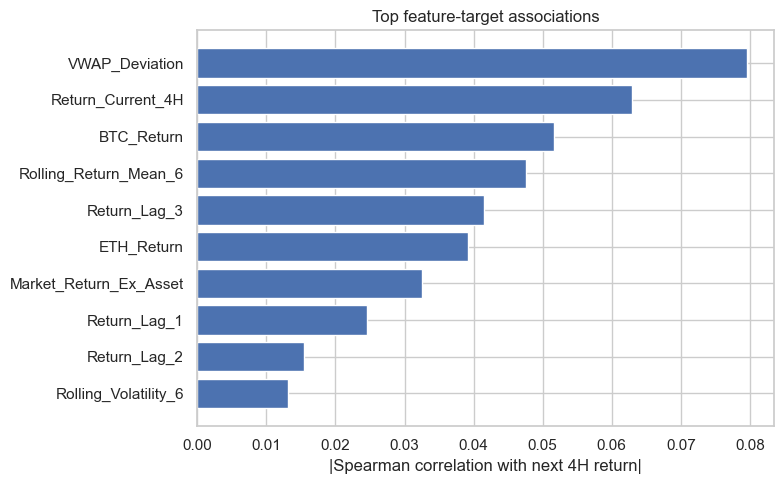

In [6]:
candidate_numeric_features = numeric_features.copy()

feature_data = train_df[candidate_numeric_features + [target_col, return_col]].replace([np.inf, -np.inf], np.nan)

association_rows = []
for feature in candidate_numeric_features:
    temp = feature_data[[feature, target_col, return_col]].dropna()
    association_rows.append({
        "feature": feature,
        "missing_share": feature_data[feature].isna().mean(),
        "spearman_with_future_return": temp[feature].corr(temp[return_col], method="spearman"),
        "corr_with_up_target": temp[feature].corr(temp[target_col]),
    })

association_df = (
    pd.DataFrame(association_rows)
    .assign(abs_spearman=lambda x: x["spearman_with_future_return"].abs())
    .sort_values("abs_spearman", ascending=False)
)

display(association_df.drop(columns="abs_spearman").round(5))

plt.figure(figsize=(8, 5))
plot_df = association_df.head(10).sort_values("abs_spearman")
plt.barh(plot_df["feature"], plot_df["abs_spearman"])
plt.title("Top feature-target associations")
plt.xlabel("|Spearman correlation with next 4H return|")
plt.tight_layout()
plt.show()

<a id="correlation-redundancy"></a>

### 5.3 Correlation and Redundancy

This checks whether several features carry almost the same information. Highly correlated features are not automatically wrong, but they should not all be treated as independent signals.

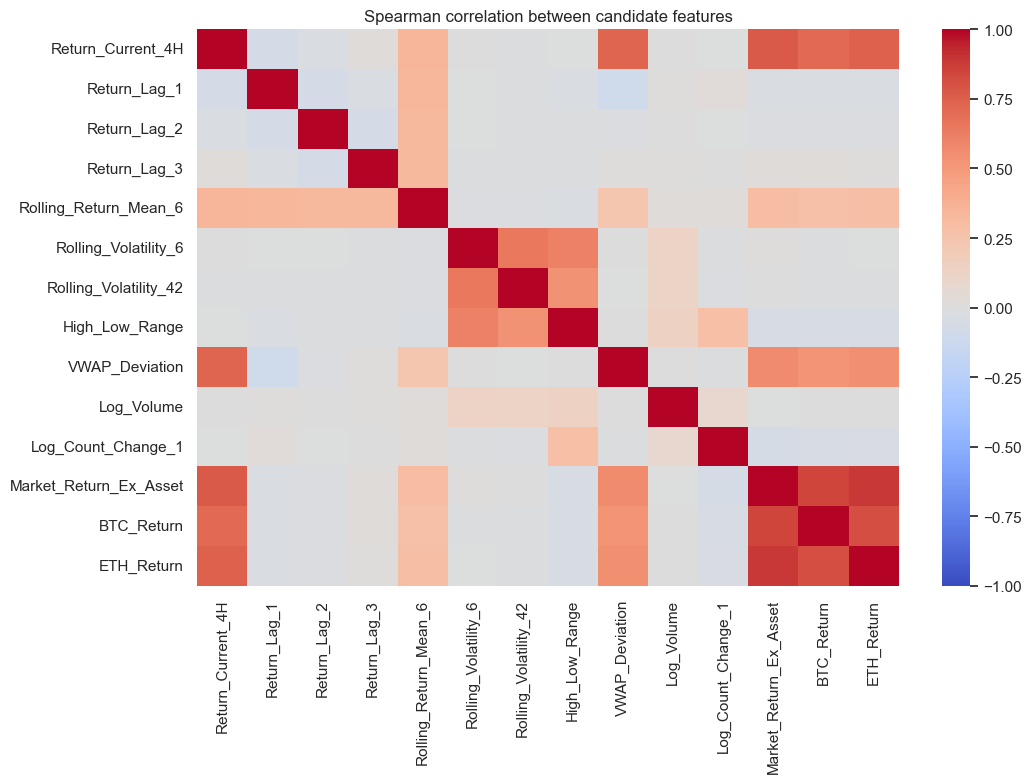

,feature_1,feature_2,spearman_corr
5,Market_Return_Ex_Asset,ETH_Return,0.8838
4,Market_Return_Ex_Asset,BTC_Return,0.8439
6,BTC_Return,ETH_Return,0.8157
1,Return_Current_4H,Market_Return_Ex_Asset,0.7695
3,Return_Current_4H,ETH_Return,0.7437
0,Return_Current_4H,VWAP_Deviation,0.7270
2,Return_Current_4H,BTC_Return,0.7150


In [7]:
feature_corr = feature_data[candidate_numeric_features].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(feature_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation between candidate features")
plt.tight_layout()
plt.show()

redundancy_rows = []
for i, left in enumerate(candidate_numeric_features):
    for right in candidate_numeric_features[i + 1:]:
        rho = feature_corr.loc[left, right]
        if pd.notna(rho) and abs(rho) >= 0.70:
            redundancy_rows.append({
                "feature_1": left,
                "feature_2": right,
                "spearman_corr": rho,
                "abs_corr": abs(rho),
            })

redundancy_df = pd.DataFrame(redundancy_rows)
if redundancy_df.empty:
    print("No feature pairs with |Spearman correlation| >= 0.70.")
else:
    redundancy_df = redundancy_df.sort_values("abs_corr", ascending=False)
    display(redundancy_df.drop(columns="abs_corr").round(4))

<a id="model-based-feature-importance"></a>

### 5.4 Model-Based Feature Importance

Following the class notebooks, we use simple, interpretable models for feature analysis: Logistic Regression coefficients, Decision Trees with different depths, and permutation importance. This is not the final model yet; it is a feature-selection diagnostic.

Decision Tree validation ROC AUC by depth:


,max_depth,validation_roc_auc
0,2,0.5615
1,3,0.5446
2,4,0.5402
3,5,0.5357


Combined feature importance summary:


,feature,group,spearman_with_future_return,corr_with_up_target,abs_logistic_coefficient,tree_importance,permutation_importance,combined_rank
0,Rolling_Return_Mean_6,trend,-0.04753,-0.04709,0.36512,0.40274,0.06246,1.750
1,VWAP_Deviation,candle pressure,-0.07952,-0.07936,0.21511,0.17532,0.04092,2.000
2,Return_Lag_3,own returns,0.04155,0.03068,0.22787,0.11928,0.00689,4.000
3,Return_Lag_2,own returns,0.01543,0.01232,0.19447,0.03007,0.02736,5.500
4,BTC_Return,cross-asset,-0.05159,-0.04701,0.04604,0.13109,0.00297,5.750
5,Return_Current_4H,own returns,-0.06290,-0.06076,0.18678,0.00000,0.00851,5.875
6,ETH_Return,cross-asset,-0.03912,-0.03847,0.07182,0.11280,0.00583,6.250
7,Return_Lag_1,own returns,-0.02456,-0.02063,0.10583,0.00350,0.00625,7.500
8,Market_Return_Ex_Asset,cross-asset,-0.03260,-0.03772,0.04866,0.00379,0.00038,8.500
9,Rolling_Volatility_6,volatility,0.01313,0.01590,0.04300,0.01241,-0.00028,10.250


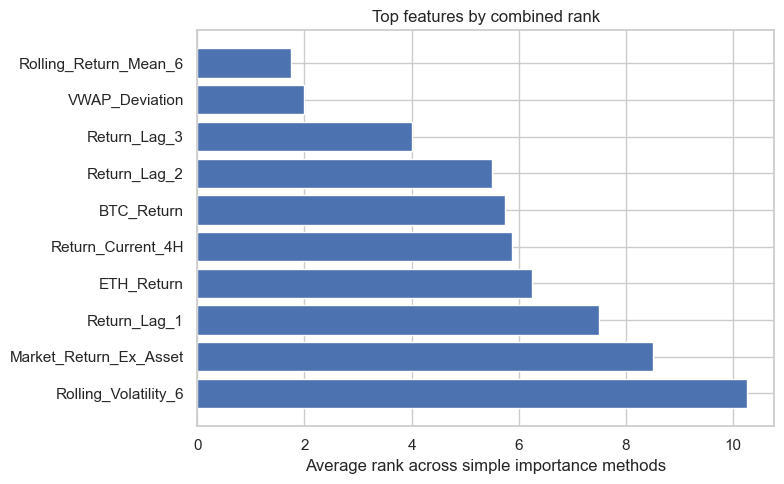

In [8]:
X_analysis_train = train_tuning_df[candidate_numeric_features]
y_analysis_train = train_tuning_df[target_col]
X_analysis_validation = validation_df[candidate_numeric_features]
y_analysis_validation = validation_df[target_col]

numeric_analysis_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

logistic_feature_model = Pipeline(steps=[
    ("preprocess", numeric_analysis_preprocess),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
])
logistic_feature_model.fit(X_analysis_train, y_analysis_train)

logistic_coef_df = pd.DataFrame({
    "feature": candidate_numeric_features,
    "logistic_coefficient": logistic_feature_model.named_steps["classifier"].coef_[0],
})
logistic_coef_df["abs_logistic_coefficient"] = logistic_coef_df["logistic_coefficient"].abs()

tree_rows = []
tree_importance_rows = []
for depth in [2, 3, 4, 5]:
    tree_feature_model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", DecisionTreeClassifier(max_depth=depth, min_samples_leaf=200, random_state=SEED)),
    ])
    tree_feature_model.fit(X_analysis_train, y_analysis_train)
    validation_proba = tree_feature_model.predict_proba(X_analysis_validation)[:, 1]
    tree_rows.append({
        "max_depth": depth,
        "validation_roc_auc": roc_auc_score(y_analysis_validation, validation_proba),
    })
    for feature, importance in zip(candidate_numeric_features, tree_feature_model.named_steps["classifier"].feature_importances_):
        tree_importance_rows.append({
            "feature": feature,
            "max_depth": depth,
            "tree_importance": importance,
        })

tree_results_df = pd.DataFrame(tree_rows)
tree_importance_df = (
    pd.DataFrame(tree_importance_rows)
    .groupby("feature", as_index=False)["tree_importance"]
    .mean()
)

perm = permutation_importance(
    logistic_feature_model,
    X_analysis_validation,
    y_analysis_validation,
    scoring="roc_auc",
    n_repeats=3,
    random_state=SEED,
    n_jobs=-1,
)
perm_df = pd.DataFrame({
    "feature": candidate_numeric_features,
    "permutation_importance": perm.importances_mean,
    "permutation_std": perm.importances_std,
})

feature_scores = (
    feature_overview
    .merge(association_df[["feature", "missing_share", "spearman_with_future_return", "corr_with_up_target"]], on="feature")
    .merge(logistic_coef_df, on="feature")
    .merge(tree_importance_df, on="feature")
    .merge(perm_df, on="feature")
)
feature_scores["abs_spearman"] = feature_scores["spearman_with_future_return"].abs()

for column in ["abs_spearman", "abs_logistic_coefficient", "tree_importance", "permutation_importance"]:
    feature_scores[column + "_rank"] = feature_scores[column].rank(ascending=False, method="average")

feature_scores["combined_rank"] = feature_scores[
    ["abs_spearman_rank", "abs_logistic_coefficient_rank", "tree_importance_rank", "permutation_importance_rank"]
].mean(axis=1)

feature_scores = feature_scores.sort_values("combined_rank").reset_index(drop=True)

print("Decision Tree validation ROC AUC by depth:")
display(tree_results_df.round(4))

print("Combined feature importance summary:")
display(
    feature_scores[
        [
            "feature", "group", "spearman_with_future_return", "corr_with_up_target",
            "abs_logistic_coefficient", "tree_importance", "permutation_importance", "combined_rank"
        ]
    ].round(5)
)

plt.figure(figsize=(8, 5))
plot_df = feature_scores.head(10).sort_values("combined_rank", ascending=False)
plt.barh(plot_df["feature"], plot_df["combined_rank"])
plt.title("Top features by combined rank")
plt.xlabel("Average rank across simple importance methods")
plt.tight_layout()
plt.show()

<a id="pdp-ice"></a>

### 5.5 PDP and ICE Plots for the Top Features

PDP shows the average model response when one feature changes. ICE shows individual observations. With financial data the curves are often noisy, but they help check whether the model behavior is plausible.

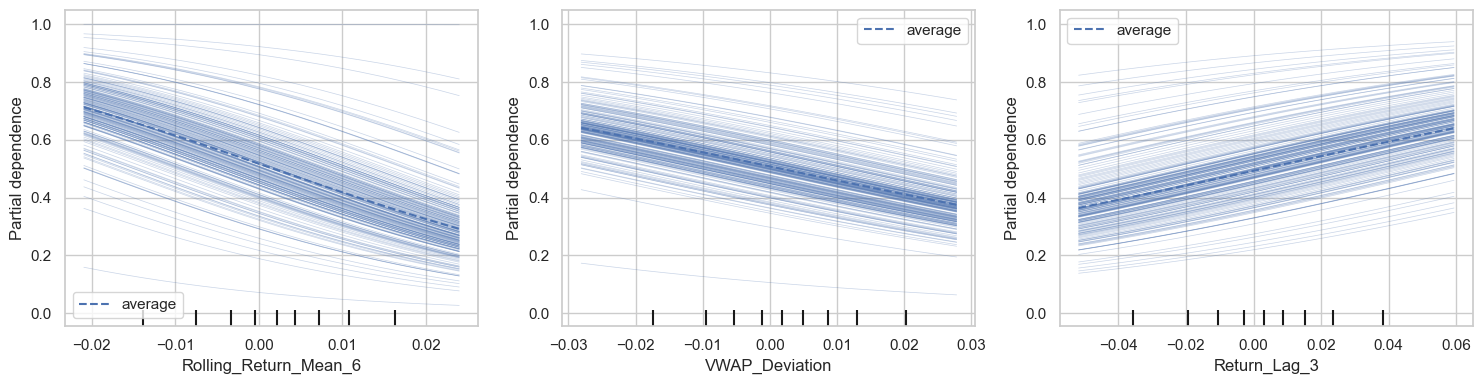

In [9]:
top_pdp_features = feature_scores.head(3)["feature"].tolist()

fig, ax = plt.subplots(1, len(top_pdp_features), figsize=(5 * len(top_pdp_features), 4))
if len(top_pdp_features) == 1:
    ax = [ax]

PartialDependenceDisplay.from_estimator(
    logistic_feature_model,
    X_analysis_validation.sample(min(1000, len(X_analysis_validation)), random_state=SEED),
    features=top_pdp_features,
    kind="both",
    subsample=200,
    grid_resolution=20,
    random_state=SEED,
    ax=ax,
)
plt.tight_layout()
plt.show()

<a id="include-neglect"></a>

### 5.6 Final Include / Neglect Decision

To keep the model simple, we include the eight best-ranked numeric features. The remaining numeric features are not deleted from the data; they are deliberately neglected for the final model because they add weaker or more redundant information in this analysis.

In [10]:
selected_numeric_features = feature_scores.head(8)["feature"].tolist()

feature_decision = feature_scores.copy()
feature_decision["decision"] = np.where(
    feature_decision["feature"].isin(selected_numeric_features),
    "Include",
    "Neglect",
)
feature_decision["reason"] = np.where(
    feature_decision["decision"].eq("Include"),
    "stronger combined evidence from EDA, trees, logistic coefficients and permutation importance",
    "weaker or more redundant signal in the simple feature analysis",
)

display(
    feature_decision[
        [
            "feature", "group", "decision", "reason",
            "spearman_with_future_return", "tree_importance",
            "abs_logistic_coefficient", "permutation_importance",
        ]
    ].round(5)
)

numeric_features = selected_numeric_features
feature_columns = numeric_features + categorical_features

X_train = train_df[feature_columns]
X_validation = validation_df[feature_columns]
X_test = test_df[feature_columns]
X_train_tuning = train_tuning_df[feature_columns]

print("Numeric features included in the final models:")
print(numeric_features)
print("Numeric features neglected:")
print([feature for feature in candidate_numeric_features if feature not in numeric_features])

,feature,group,decision,reason,spearman_with_future_return,tree_importance,abs_logistic_coefficient,permutation_importance
0,Rolling_Return_Mean_6,trend,Include,"stronger combined evidence from EDA, trees, lo...",-0.04753,0.40274,0.36512,0.06246
1,VWAP_Deviation,candle pressure,Include,"stronger combined evidence from EDA, trees, lo...",-0.07952,0.17532,0.21511,0.04092
2,Return_Lag_3,own returns,Include,"stronger combined evidence from EDA, trees, lo...",0.04155,0.11928,0.22787,0.00689
3,Return_Lag_2,own returns,Include,"stronger combined evidence from EDA, trees, lo...",0.01543,0.03007,0.19447,0.02736
4,BTC_Return,cross-asset,Include,"stronger combined evidence from EDA, trees, lo...",-0.05159,0.13109,0.04604,0.00297
5,Return_Current_4H,own returns,Include,"stronger combined evidence from EDA, trees, lo...",-0.06290,0.00000,0.18678,0.00851
6,ETH_Return,cross-asset,Include,"stronger combined evidence from EDA, trees, lo...",-0.03912,0.11280,0.07182,0.00583
7,Return_Lag_1,own returns,Include,"stronger combined evidence from EDA, trees, lo...",-0.02456,0.00350,0.10583,0.00625
8,Market_Return_Ex_Asset,cross-asset,Neglect,weaker or more redundant signal in the simple ...,-0.03260,0.00379,0.04866,0.00038
9,Rolling_Volatility_6,volatility,Neglect,weaker or more redundant signal in the simple ...,0.01313,0.01241,0.04300,-0.00028


Numeric features included in the final models:
['Rolling_Return_Mean_6', 'VWAP_Deviation', 'Return_Lag_3', 'Return_Lag_2', 'BTC_Return', 'Return_Current_4H', 'ETH_Return', 'Return_Lag_1']
Numeric features neglected:
['Rolling_Volatility_6', 'Rolling_Volatility_42', 'High_Low_Range', 'Log_Volume', 'Log_Count_Change_1', 'Market_Return_Ex_Asset']


<a id="modeling"></a>

## 6. Modeling

Following the course notebooks, all preprocessing is inside a scikit-learn `Pipeline`. Numeric variables are median-imputed and standardized. The categorical asset name is imputed and one-hot encoded. This prevents data leakage because the imputer, scaler and encoder are fit only on the training fold during cross-validation.

We compare the six models discussed for the project:

1. Logistic Regression;
2. KNN;
3. Decision Tree;
4. Random Forest;
5. Gradient Boosting;
6. Neural Network.

The first five are tuned together as classical models. The neural network is trained separately, as requested in the assignment.

In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


def get_positive_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1 / (1 + np.exp(-scores))


def classification_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "average_precision": average_precision_score(y_true, y_proba),
    }


def evaluate_classifier(model, X, y, threshold=0.50):
    y_proba = get_positive_proba(model, X)
    y_pred = (y_proba >= threshold).astype(int)
    return classification_metrics(y, y_pred, y_proba)


def trading_metrics(evaluation_df, proba, threshold=0.50, transaction_cost=TRANSACTION_COST):
    temp = evaluation_df[["timestamp", "Asset_ID", return_col]].copy()
    temp["proba_up"] = proba
    temp["position"] = (temp["proba_up"] >= threshold).astype(int)
    temp = temp.sort_values(["Asset_ID", "timestamp"])
    temp["trade"] = temp.groupby("Asset_ID")["position"].diff().abs().fillna(temp["position"])
    temp["strategy_return"] = temp["position"] * temp[return_col] - transaction_cost * temp["trade"]

    period_returns = temp.groupby("timestamp")["strategy_return"].mean().sort_index()
    cumulative_return = np.exp(period_returns.sum()) - 1
    periods_per_year = 6 * 365
    sharpe = np.sqrt(periods_per_year) * period_returns.mean() / period_returns.std() if period_returns.std() > 0 else np.nan
    equity_curve = np.exp(period_returns.cumsum())
    max_drawdown = (equity_curve / equity_curve.cummax() - 1).min()

    return {
        "threshold": threshold,
        "cumulative_return": cumulative_return,
        "annualized_sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "avg_position_rate": temp["position"].mean(),
        "turnover": temp["trade"].mean(),
        "n_trades": int(temp["trade"].sum()),
    }


def buy_and_hold_metrics(evaluation_df):
    period_returns = evaluation_df.groupby("timestamp")[return_col].mean().sort_index()
    cumulative_return = np.exp(period_returns.sum()) - 1
    periods_per_year = 6 * 365
    sharpe = np.sqrt(periods_per_year) * period_returns.mean() / period_returns.std() if period_returns.std() > 0 else np.nan
    equity_curve = np.exp(period_returns.cumsum())
    max_drawdown = (equity_curve / equity_curve.cummax() - 1).min()
    return {
        "cumulative_return": cumulative_return,
        "annualized_sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "avg_position_rate": 1.0,
        "turnover": 0.0,
        "n_trades": 0,
    }


def select_threshold_on_validation(model, X_val, y_val, validation_frame, thresholds=np.arange(0.50, 0.651, 0.01)):
    proba = get_positive_proba(model, X_val)
    rows = []
    for threshold in thresholds:
        y_pred = (proba >= threshold).astype(int)
        cls = classification_metrics(y_val, y_pred, proba)
        trd = trading_metrics(validation_frame, proba, threshold=threshold)
        rows.append({"threshold": threshold, **cls, **trd})
    results = pd.DataFrame(rows)
    feasible = results[results["avg_position_rate"] >= 0.05]
    if feasible.empty:
        feasible = results
    best = feasible.sort_values(["annualized_sharpe", "roc_auc"], ascending=False).iloc[0]
    return float(best["threshold"]), results

<a id="baseline-models"></a>

### 6.1 Baseline Models

Before fitting complex models, we need baselines. The majority-class baseline checks whether accuracy is misleading in a nearly balanced target. The stratified baseline represents random class predictions with the same class distribution as the training data.

In [12]:
baseline_rows = []
for strategy in ["most_frequent", "stratified"]:
    baseline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("classifier", DummyClassifier(strategy=strategy, random_state=SEED)),
    ])
    baseline.fit(X_train, y_train)
    metrics = evaluate_classifier(baseline, X_validation, y_validation)
    baseline_rows.append({"model": f"DummyClassifier({strategy})", **metrics})

baseline_results_df = pd.DataFrame(baseline_rows)
display(baseline_results_df)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,DummyClassifier(most_frequent),0.535150,0.500000,0.535150,1.000000,0.697196,0.500000,0.535150
1,DummyClassifier(stratified),0.497877,0.497399,0.532596,0.504204,0.518011,0.497399,0.533862


<a id="classical-models"></a>

### 6.2 Classical Models with Time-Aware Hyperparameter Tuning

Each model is tuned with at least two hyperparameters, following the grid-search approach used in the class notebooks. We optimize ROC AUC because it evaluates the ranking quality of predicted probabilities independently of a fixed threshold. This is appropriate because the final trading threshold is selected after probability estimation.

In [13]:
tscv = TimeSeriesSplit(n_splits=3)

model_specs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, solver="lbfgs", random_state=SEED),
        "param_grid": {
            "classifier__C": [0.1, 1.0, 10.0],
            "classifier__class_weight": [None, "balanced"],
        },
    },
    "KNN": {
        "estimator": KNeighborsClassifier(n_jobs=-1),
        "param_grid": {
            "classifier__n_neighbors": [25, 75],
            "classifier__weights": ["uniform", "distance"],
        },
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=SEED),
        "param_grid": {
            "classifier__max_depth": [3, 6, 10],
            "classifier__min_samples_leaf": [100, 500],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(n_estimators=80, n_jobs=-1, random_state=SEED),
        "param_grid": {
            "classifier__max_depth": [4, 8],
            "classifier__min_samples_leaf": [100, 500],
            "classifier__max_features": ["sqrt", 0.5],
        },
    },
    "Gradient Boosting": {
        "estimator": HistGradientBoostingClassifier(random_state=SEED),
        "param_grid": {
            "classifier__learning_rate": [0.03, 0.10],
            "classifier__max_leaf_nodes": [15, 31],
            "classifier__l2_regularization": [0.0, 0.1],
        },
    },
}

search_rows = []
best_models = {}
threshold_tables = {}

for model_name, spec in model_specs.items():
    print(f"\n--- Tuning {model_name} ---")
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("classifier", spec["estimator"]),
    ])
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=spec["param_grid"],
        scoring="roc_auc",
        cv=tscv,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train_tuning, y_train_tuning)

    best_model = clone(grid.best_estimator_)
    best_model.fit(X_train, y_train)
    best_models[model_name] = best_model

    validation_metrics = evaluate_classifier(best_model, X_validation, y_validation)
    best_threshold, threshold_table = select_threshold_on_validation(best_model, X_validation, y_validation, validation_df)
    threshold_tables[model_name] = threshold_table

    search_rows.append({
        "model": model_name,
        "best_cv_roc_auc": grid.best_score_,
        "validation_threshold": best_threshold,
        **validation_metrics,
        "best_params": grid.best_params_,
    })

    print("Best CV ROC AUC:", round(grid.best_score_, 4))
    print("Best params:", grid.best_params_)
    print("Validation ROC AUC:", round(validation_metrics["roc_auc"], 4), "| F1@0.50:", round(validation_metrics["f1"], 4), "| threshold:", round(best_threshold, 2))

classical_results_df = pd.DataFrame(search_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(classical_results_df.drop(columns="best_params"))
display(classical_results_df[["model", "best_params"]])


--- Tuning Logistic Regression ---


Best CV ROC AUC: 0.5783
Best params: {'classifier__C': 0.1, 'classifier__class_weight': None}
Validation ROC AUC: 0.5606 | F1@0.50: 0.5552 | threshold: 0.52

--- Tuning KNN ---


Best CV ROC AUC: 0.5473
Best params: {'classifier__n_neighbors': 75, 'classifier__weights': 'distance'}
Validation ROC AUC: 0.5296 | F1@0.50: 0.5216 | threshold: 0.65

--- Tuning Decision Tree ---


Best CV ROC AUC: 0.5455
Best params: {'classifier__max_depth': 6, 'classifier__min_samples_leaf': 100}
Validation ROC AUC: 0.5416 | F1@0.50: 0.5382 | threshold: 0.51

--- Tuning Random Forest ---


Best CV ROC AUC: 0.5677
Best params: {'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 100}
Validation ROC AUC: 0.5638 | F1@0.50: 0.5476 | threshold: 0.53

--- Tuning Gradient Boosting ---


Best CV ROC AUC: 0.5613
Best params: {'classifier__l2_regularization': 0.1, 'classifier__learning_rate': 0.03, 'classifier__max_leaf_nodes': 15}
Validation ROC AUC: 0.5476 | F1@0.50: 0.5428 | threshold: 0.5


,model,best_cv_roc_auc,validation_threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.567660,0.53,0.548226,0.551038,0.589927,0.511026,0.547649,0.563754,0.589407
1,Logistic Regression,0.578285,0.52,0.547461,0.548957,0.585666,0.527685,0.555166,0.560554,0.580928
2,Gradient Boosting,0.561313,0.50,0.543216,0.545974,0.584446,0.506743,0.542828,0.547607,0.568586
3,Decision Tree,0.545523,0.51,0.538716,0.541470,0.579641,0.502300,0.538207,0.541570,0.569668
4,KNN,0.547276,0.65,0.517575,0.519546,0.555695,0.491512,0.521637,0.529557,0.565389


,model,best_params
0,Random Forest,"{'classifier__max_depth': 4, 'classifier__max_..."
1,Logistic Regression,"{'classifier__C': 0.1, 'classifier__class_weig..."
2,Gradient Boosting,"{'classifier__l2_regularization': 0.1, 'classi..."
3,Decision Tree,"{'classifier__max_depth': 6, 'classifier__min_..."
4,KNN,"{'classifier__n_neighbors': 75, 'classifier__w..."


<a id="classical-model-interpretation"></a>

### 6.3 Interpretation of the Classical Model Comparison

All classical models perform only modestly above random, which is a sensible result for high-frequency financial direction prediction. Random Forest and Logistic Regression are the strongest validation models. Logistic Regression being competitive suggests that part of the signal is approximately linear, while Random Forest slightly improves validation ROC AUC by allowing non-linear interactions between return, volatility, liquidity and market-context features.

KNN and Decision Tree are weaker. KNN suffers because similar historical observations do not necessarily imply similar future returns in noisy markets. A single Decision Tree is interpretable but unstable. The ensemble models reduce this instability, which is why Random Forest and Gradient Boosting are more appropriate candidates.

<a id="neural-network"></a>

### 6.4 Neural Network

The neural network is trained separately. In the course notebooks this is done with Keras/TensorFlow; in this local environment TensorFlow is not installed, so we use scikit-learn's `MLPClassifier`, which is still a fully connected feed-forward neural network. We keep the same methodology: scaled inputs, early stopping, validation monitoring and hyperparameter tuning.

Best CV ROC AUC: 0.5738
Best params: {'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (32,), 'classifier__learning_rate_init': 0.001}
Validation ROC AUC: 0.5526
Selected threshold: 0.54


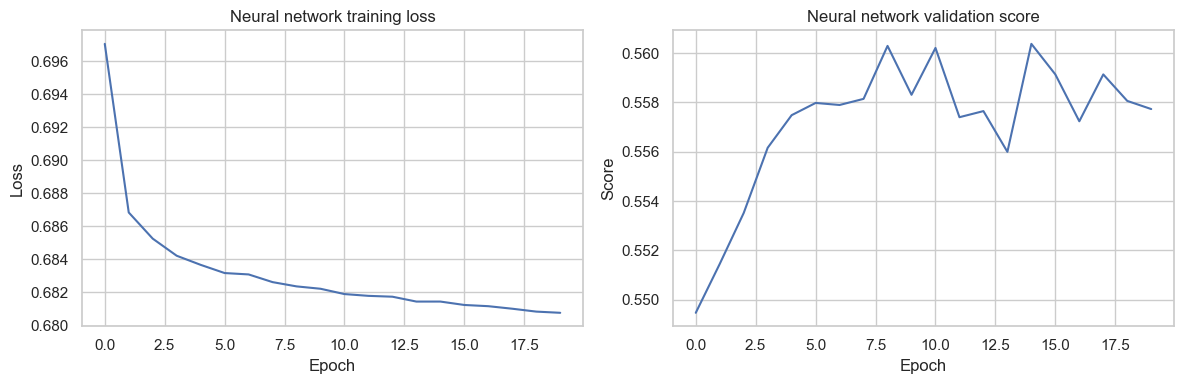

In [14]:
mlp_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", MLPClassifier(
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=SEED,
    )),
])

mlp_grid = {
    "classifier__hidden_layer_sizes": [(32,), (64, 32)],
    "classifier__alpha": [0.0001, 0.001],
    "classifier__learning_rate_init": [0.001, 0.003],
}

mlp_search = GridSearchCV(
    estimator=mlp_pipe,
    param_grid=mlp_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)

mlp_search.fit(X_train_tuning, y_train_tuning)

best_mlp = clone(mlp_search.best_estimator_)
best_mlp.fit(X_train, y_train)
best_models["Neural Network"] = best_mlp

mlp_validation_metrics = evaluate_classifier(best_mlp, X_validation, y_validation)
mlp_threshold, mlp_threshold_table = select_threshold_on_validation(best_mlp, X_validation, y_validation, validation_df)
threshold_tables["Neural Network"] = mlp_threshold_table

mlp_row = {
    "model": "Neural Network",
    "best_cv_roc_auc": mlp_search.best_score_,
    "validation_threshold": mlp_threshold,
    **mlp_validation_metrics,
    "best_params": mlp_search.best_params_,
}

print("Best CV ROC AUC:", round(mlp_search.best_score_, 4))
print("Best params:", mlp_search.best_params_)
print("Validation ROC AUC:", round(mlp_validation_metrics["roc_auc"], 4))
print("Selected threshold:", round(mlp_threshold, 2))

mlp_classifier = best_mlp.named_steps["classifier"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(mlp_classifier.loss_curve_)
ax[0].set_title("Neural network training loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")

if hasattr(mlp_classifier, "validation_scores_"):
    ax[1].plot(mlp_classifier.validation_scores_)
    ax[1].set_title("Neural network validation score")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Score")
else:
    ax[1].axis("off")

plt.tight_layout()
plt.show()

<a id="neural-network-interpretation"></a>

### 6.5 Interpretation of the Neural Network Results

The neural network is competitive but does not clearly dominate the simpler models. This is important because neural networks can easily overfit noisy financial data. The loss curve and validation-score curve help us check whether training is stable. In this project, the neural network is useful to satisfy the assignment requirement and to test non-linear interactions, but it is not automatically preferred over Random Forest or Logistic Regression.

<a id="model-evaluation"></a>

## 7. Model Evaluation

Model selection is based on validation ROC AUC, because ROC AUC evaluates the quality of the probability ranking before choosing a trading threshold. The trading threshold is selected on the validation period by maximizing validation Sharpe ratio subject to minimum exposure. The final test set is used once, after choosing the model and threshold on validation data.

The trading rule is intentionally simple: long if `P(up)` is above the selected threshold, no position otherwise. Transaction costs are included as a conservative penalty when positions change.

In [15]:
all_validation_results = pd.concat([
    classical_results_df,
    pd.DataFrame([mlp_row]),
], ignore_index=True).sort_values("roc_auc", ascending=False).reset_index(drop=True)

print("Validation comparison:")
display(all_validation_results.drop(columns="best_params"))

final_model_name = all_validation_results.iloc[0]["model"]
final_threshold = float(all_validation_results.iloc[0]["validation_threshold"])
final_model = best_models[final_model_name]

print("Final selected model:", final_model_name)
print("Final selected threshold:", round(final_threshold, 2))

Validation comparison:


,model,best_cv_roc_auc,validation_threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.567660,0.53,0.548226,0.551038,0.589927,0.511026,0.547649,0.563754,0.589407
1,Logistic Regression,0.578285,0.52,0.547461,0.548957,0.585666,0.527685,0.555166,0.560554,0.580928
2,Neural Network,0.573839,0.54,0.545424,0.544414,0.577851,0.558782,0.568156,0.552625,0.575282
3,Gradient Boosting,0.561313,0.50,0.543216,0.545974,0.584446,0.506743,0.542828,0.547607,0.568586
4,Decision Tree,0.545523,0.51,0.538716,0.541470,0.579641,0.502300,0.538207,0.541570,0.569668
5,KNN,0.547276,0.65,0.517575,0.519546,0.555695,0.491512,0.521637,0.529557,0.565389


Final selected model: Random Forest
Final selected threshold: 0.53


In [16]:
def evaluate_on_test(model_name, model, threshold):
    proba = get_positive_proba(model, X_test)
    pred_050 = (proba >= 0.50).astype(int)
    pred_selected = (proba >= threshold).astype(int)
    cls_050 = classification_metrics(y_test, pred_050, proba)
    cls_selected = classification_metrics(y_test, pred_selected, proba)
    trd = trading_metrics(test_df, proba, threshold=threshold)
    return proba, pred_selected, cls_050, cls_selected, trd


test_rows = []
test_probabilities = {}
for _, row in all_validation_results.iterrows():
    model_name = row["model"]
    threshold = float(row["validation_threshold"])
    proba, pred_selected, cls_050, cls_selected, trd = evaluate_on_test(model_name, best_models[model_name], threshold)
    test_probabilities[model_name] = proba
    test_rows.append({
        "model": model_name,
        "threshold": threshold,
        "roc_auc": cls_selected["roc_auc"],
        "f1_at_threshold": cls_selected["f1"],
        "precision_at_threshold": cls_selected["precision"],
        "recall_at_threshold": cls_selected["recall"],
        **trd,
    })

test_results_df = pd.DataFrame(test_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
print("Test results for all tuned models:")
display(test_results_df)

final_proba = test_probabilities[final_model_name]
final_pred = (final_proba >= final_threshold).astype(int)

print("Classification report for final model on test set:")
print(classification_report(y_test, final_pred, zero_division=0))
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_test, final_pred), index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))

Test results for all tuned models:


,model,threshold,roc_auc,f1_at_threshold,precision_at_threshold,recall_at_threshold,cumulative_return,annualized_sharpe,max_drawdown,avg_position_rate,turnover,n_trades
0,Random Forest,0.53,0.566636,0.449426,0.562522,0.374194,-0.118644,-0.726166,-0.240086,0.330964,0.406855,3549
1,Neural Network,0.54,0.560845,0.456746,0.557437,0.386866,-0.018810,-0.136173,-0.210399,0.345294,0.423364,3693
2,Logistic Regression,0.52,0.550333,0.442204,0.551879,0.368894,0.062788,0.408401,-0.188699,0.332569,0.421759,3679
3,Gradient Boosting,0.50,0.548958,0.532628,0.543818,0.521889,-0.067571,-0.370755,-0.342250,0.477473,0.449731,3923
4,KNN,0.65,0.544394,0.082303,0.551429,0.044470,-0.009180,-0.356709,-0.042277,0.040124,0.074974,654
5,Decision Tree,0.51,0.540879,0.493349,0.547988,0.448618,-0.015572,-0.094741,-0.257339,0.407314,0.423020,3690


Classification report for final model on test set:
              precision    recall  f1-score   support

           0       0.53      0.71      0.61      4383
           1       0.56      0.37      0.45      4340

    accuracy                           0.54      8723
   macro avg       0.55      0.54      0.53      8723
weighted avg       0.55      0.54      0.53      8723

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,3120,1263
Actual 1,2716,1624


,strategy,threshold,cumulative_return,annualized_sharpe,max_drawdown,avg_position_rate,turnover,n_trades
0,ML long/no-position,0.53,-0.118644,-0.726166,-0.240086,0.330964,0.406855,3549
1,Equal-weight buy-and-hold,NaN,-0.087892,-0.319740,-0.454615,1.000000,0.000000,0


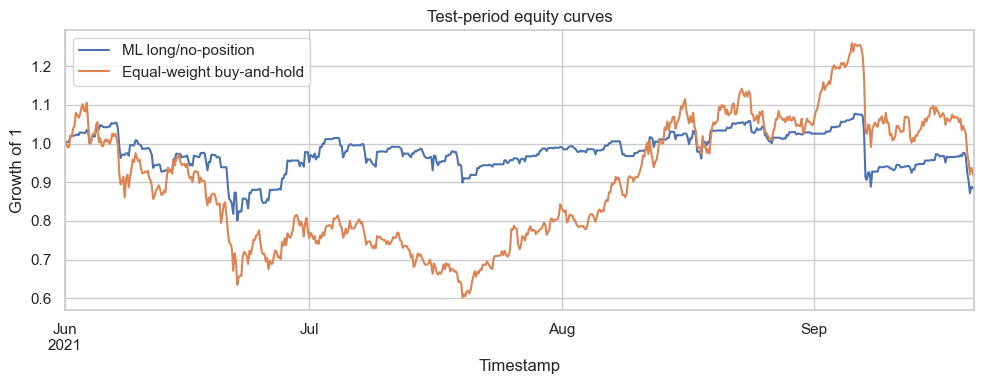

In [17]:
buy_hold = buy_and_hold_metrics(test_df)
strategy = trading_metrics(test_df, final_proba, threshold=final_threshold)

trading_comparison = pd.DataFrame([
    {"strategy": "ML long/no-position", **strategy},
    {"strategy": "Equal-weight buy-and-hold", **buy_hold},
])

display(trading_comparison)

backtest_df = test_df[["timestamp", "Asset_ID", return_col]].copy()
backtest_df["proba_up"] = final_proba
backtest_df["position"] = (backtest_df["proba_up"] >= final_threshold).astype(int)
backtest_df = backtest_df.sort_values(["Asset_ID", "timestamp"])
backtest_df["trade"] = backtest_df.groupby("Asset_ID")["position"].diff().abs().fillna(backtest_df["position"])
backtest_df["strategy_return"] = backtest_df["position"] * backtest_df[return_col] - TRANSACTION_COST * backtest_df["trade"]

strategy_period_returns = backtest_df.groupby("timestamp")["strategy_return"].mean().sort_index()
buy_hold_period_returns = test_df.groupby("timestamp")[return_col].mean().sort_index()

equity_curves = pd.DataFrame({
    "ML long/no-position": np.exp(strategy_period_returns.cumsum()),
    "Equal-weight buy-and-hold": np.exp(buy_hold_period_returns.cumsum()),
})

equity_curves.plot(figsize=(10, 4))
plt.title("Test-period equity curves")
plt.ylabel("Growth of 1")
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

<a id="final-test-interpretation"></a>

### 7.1 Interpretation of the Final Test Results

The Random Forest is selected because it has the highest validation ROC AUC. On the test period it reaches ROC AUC around 0.567 and accuracy around 54%, which is modest but above the random baseline expected for a nearly balanced target. This is realistic for short-horizon crypto direction forecasting: the problem is noisy and we should not expect very high classification accuracy.

The trading backtest is the more relevant business output. In this run, the final long/no-position strategy does not beat the equal-weight buy-and-hold benchmark on cumulative return or Sharpe ratio, although it has a smaller maximum drawdown because it is not always invested. This is an important result: the model has some directional signal, but the trading edge is weak and not strong enough to claim a profitable strategy.

<a id="model-interpretation"></a>

## 8. Model Interpretation

The feature-analysis section already used EDA checks, Decision Trees, Logistic Regression, permutation importance, PDP and ICE before final model fitting. After selecting the final model, we use two compact interpretation checks from the course notebooks: Logistic Regression coefficients for the linear benchmark and permutation importance for the selected Random Forest model.

Largest absolute Logistic Regression coefficients:


,feature,coefficient,abs_coefficient
0,num__Rolling_Return_Mean_6,-0.191542,0.191542
1,num__VWAP_Deviation,-0.178876,0.178876
2,num__Return_Lag_3,0.142235,0.142235
3,num__Return_Lag_2,0.100531,0.100531
6,num__ETH_Return,0.076742,0.076742
9,cat__Asset_Name_Bitcoin,0.071636,0.071636
5,num__Return_Current_4H,0.069105,0.069105
4,num__BTC_Return,-0.055187,0.055187
12,cat__Asset_Name_Dogecoin,-0.041225,0.041225
15,cat__Asset_Name_Ethereum Classic,-0.036458,0.036458


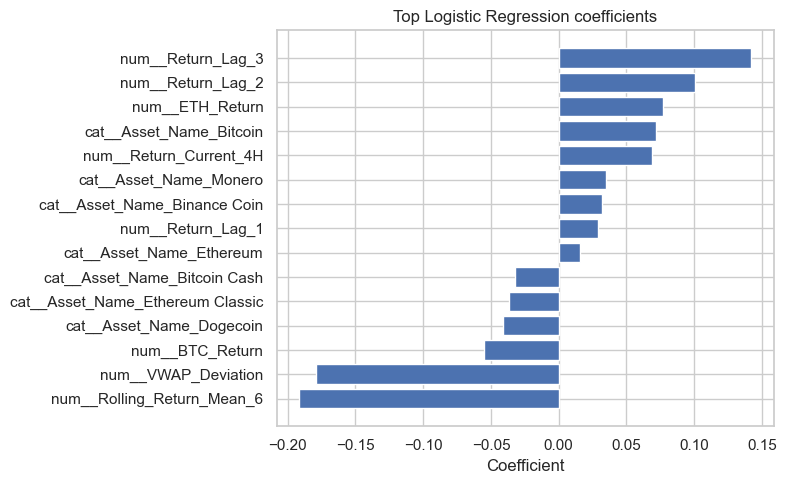

In [18]:
logistic_model = best_models["Logistic Regression"]
feature_names = logistic_model.named_steps["preprocess"].get_feature_names_out()
logistic_coef = logistic_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logistic_coef,
    "abs_coefficient": np.abs(logistic_coef),
}).sort_values("abs_coefficient", ascending=False)

print("Largest absolute Logistic Regression coefficients:")
display(coef_df.head(20))

plt.figure(figsize=(8, 5))
plot_df = coef_df.head(15).sort_values("coefficient")
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.title("Top Logistic Regression coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

Permutation importance for final model:


,feature,importance_mean,importance_std
1,VWAP_Deviation,0.011383,0.011654
4,BTC_Return,0.006965,0.000494
5,Return_Current_4H,0.002428,0.005722
6,ETH_Return,0.002262,0.002678
8,Asset_Name,0.000518,0.000520
2,Return_Lag_3,-0.002143,0.001746
0,Rolling_Return_Mean_6,-0.002500,0.002445
3,Return_Lag_2,-0.002870,0.000540
7,Return_Lag_1,-0.007349,0.001380


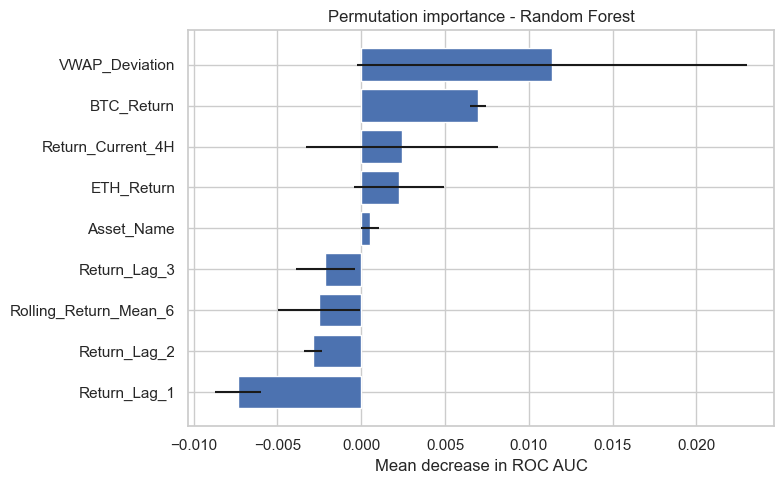

In [19]:
interpretation_size = min(1500, len(X_test))
X_interpret = X_test.sample(n=interpretation_size, random_state=SEED)
y_interpret = y_test.loc[X_interpret.index]

perm = permutation_importance(
    final_model,
    X_interpret,
    y_interpret,
    scoring="roc_auc",
    n_repeats=3,
    random_state=SEED,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

print("Permutation importance for final model:")
display(perm_df)

plt.figure(figsize=(8, 5))
plot_df = perm_df.head(12).sort_values("importance_mean")
plt.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.title(f"Permutation importance - {final_model_name}")
plt.xlabel("Mean decrease in ROC AUC")
plt.tight_layout()
plt.show()

<a id="feature-importance-interpretation"></a>

### 8.1 Interpretation of the Feature Importance Results

The interpretation results are consistent with the feature-selection section. The most relevant signals are not raw price levels, but short-term return pressure, VWAP deviation, BTC/ETH market context and asset identity. The permutation importances are small, which is expected in noisy 4-hour financial data, but the ranking is economically plausible: recent price pressure and broad market movement contain more information than distant or very noisy activity variables.

This also explains why the model should be evaluated as a trading rule rather than only as a classifier. Even modest probability improvements can be useful, but in this test period the improvement is not strong enough to produce a clearly superior trading strategy after transaction costs.

<a id="conclusion"></a>

## 9. Conclusion

This notebook builds an assignment-ready algorithmic trading model. The EDA led us to use returns rather than prices, remove Maker because of structural gaps, keep the remaining 13 assets with gap-aware targets and features, and use a compact set of return, VWAP, and market-context variables.

The final model is selected on the validation period and evaluated once on the test period. The key result is not only whether the classifier has ROC AUC above the baseline, but whether its probability forecasts can be converted into a useful trading rule after transaction costs. The feature-analysis section makes the feature choice explicit: we include the strongest signals and neglect weaker or redundant variables before fitting the final models.

The final result is deliberately cautious. The Random Forest shows modest directional signal, but the backtest does not prove a robust profitable strategy. The main contribution of the notebook is a clean machine learning process: gap-aware data preparation, chronological splitting, simple feature analysis, model comparison, final test evaluation, and honest interpretation.